In [2]:
import os
import sys
print(sys.executable)
!{sys.executable} -m pip install torch torchvision numpy matplotlib
# Set working directory
PROJECT_ROOT = "/root/AI"
os.chdir(PROJECT_ROOT)

print("Working directory:", os.getcwd())
print("Python:", sys.executable)

/root/AI/rag_part_five_env/bin/python

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Working directory: /root/AI
Python: /root/AI/rag_part_five_env/bin/python


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import MNIST
from torch import optim

In [4]:
mnist_train = MNIST(root='./data', train=True, download=True)
mnist_test = MNIST(root='./data', train=False, download=True)

transform = transforms.Compose([transforms.ToTensor()])

100.0%
100.0%
100.0%
100.0%


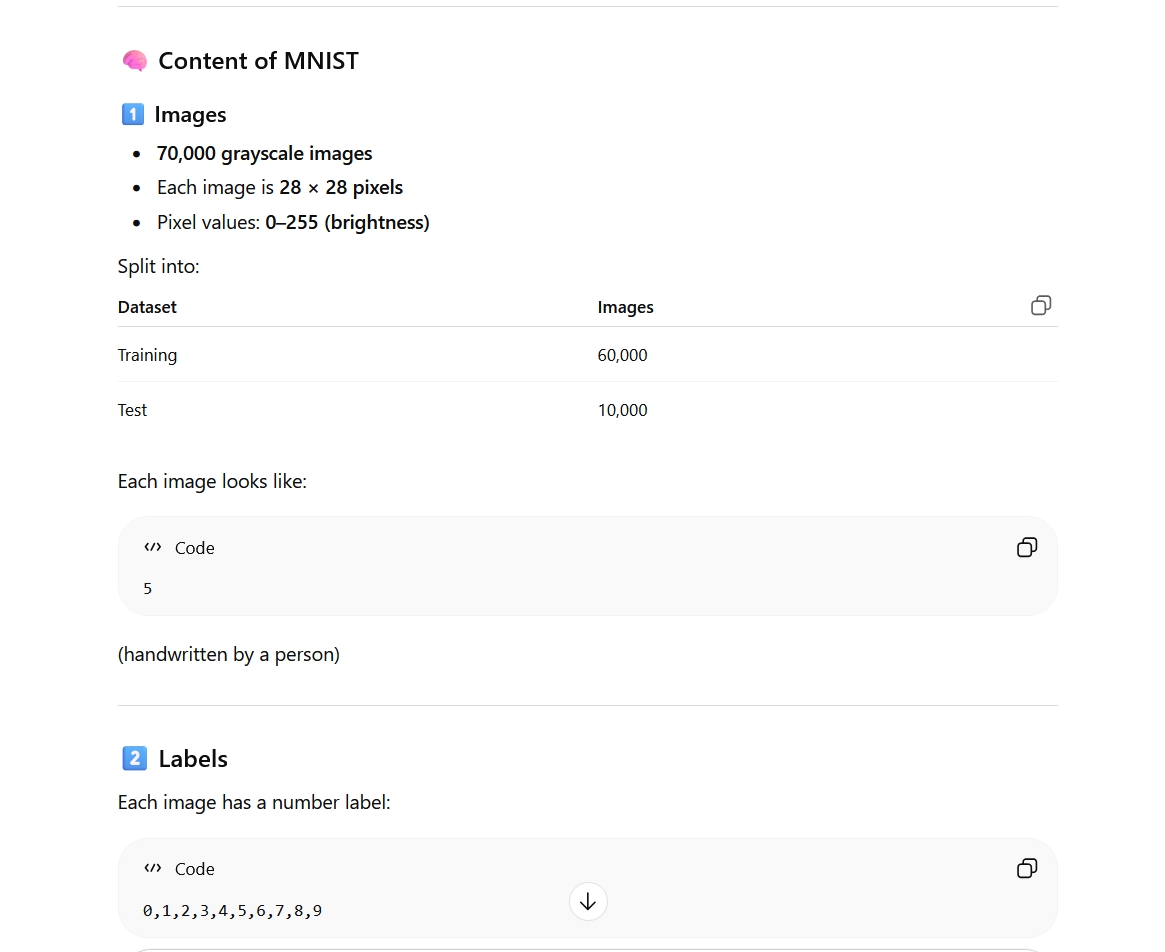

In [ ]:
class SiameseDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)  # ← return belongs here, not at the bottom

    def __getitem__(self, index):
        imgA, labelA = self.data[index]
            
        same_class_flag = random.randint(0, 1)
        
        if same_class_flag:
            labelB = -1
            while labelB != labelA:
                imgB, labelB = random.choice(self.data)
        else:
            labelB = labelA
            while labelB == labelA:
                imgB, labelB = random.choice(self.data)

        if self.transform:
            imgA = self.transform(imgA)
            imgB = self.transform(imgB)
            
        pair_label = torch.tensor([(labelA != labelB)], dtype=torch.float32)
        
        return imgA, imgB, pair_label  # ← return belongs here


In [15]:
siamese_train = SiameseDataset(mnist_train, transform)
siamese_test = SiameseDataset(mnist_test, transform)


In [18]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),

            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),

            nn.Linear(256, 2)
        )

    def forward_once(self, x):
        output = self.cnn(x)
        output = output.view(output.size()[0], -1)
        output = self.fc(output)
        return output

    def forward(self, inputA, inputB):
        outputA = self.forward_once(inputA)
        outputB = self.forward_once(inputB)
        return outputA, outputB

    
# Initiate
    net = SiameseNetwork().cuda()

In [19]:
class ContrastiveLoss(torch.nn.Module):
    
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, outputA, outputB, y):
        euclidean_distance = F.pairwise_distance(outputA, outputB, keepdim = True)

        same_class_loss = (1-y) * (euclidean_distance**2)
        diff_class_loss = (y) * (torch.clamp(self.margin - euclidean_distance, min=0.0)**2)
    
        return torch.mean(same_class_loss + diff_class_loss)

In [20]:
train_dataloader = DataLoader(siamese_train, shuffle=True, num_workers=8, batch_size=64)
model = SiameseNetwork().cuda()
criterion = ContrastiveLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [21]:
for epoch in range(5):
    total_loss = 0
    
    for imgA, imgB, label in train_dataloader:

        imgA, imgB, label = imgA.cuda(), imgB.cuda(), label.cuda()
        optimizer.zero_grad()
        outputA, outputB = net(imgA, imgB)
        loss_contrastive = criterion(outputA, outputB, label)
        loss_contrastive.backward()

        total_loss += loss_contrastive.item()
        optimizer.step()

    print(f"Epoch {epoch}; Loss {total_loss}")

NameError: name 'net' is not defined